# US Retail Sales - Time Series EDA & Preprocessing

**Data source:** FRED (Federal Reserve Economic Data)
- `RSAFSNA` — Advance Retail Sales: Retail Trade and Food Services, **Not Seasonally Adjusted** (millions of USD, monthly)
- `RSAFS` — same series, **Seasonally Adjusted**

Both run from **January 1992 to the most recent released month** (34+ years, updated monthly).

**Why this pair of series:** having both the NSA and SA versions of the same
underlying data lets us directly compare "raw" seasonality against the
Census Bureau's own seasonal adjustment — useful context before we do our
own stationarity work on the NSA series.

**Setup required before running this notebook:**
1. Get a free API key: https://fred.stlouisfed.org/docs/api/api_key.html
2. Set it as an environment variable (don't hardcode it in the notebook):
   ```bash
   export FRED_API_KEY="your_key_here"
   ```
   (On Windows: `setx FRED_API_KEY "your_key_here"`, then restart the terminal)
3. `pip install fredapi statsmodels pmdarima`

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

api_key = os.environ.get('FRED_API_KEY')
if not api_key:
    raise RuntimeError(
        "FRED_API_KEY environment variable not set. "
        "Get a free key at https://fred.stlouisfed.org/docs/api/api_key.html "
        "and set it with: export FRED_API_KEY='your_key_here'"
    )

fred = Fred(api_key=api_key)


# 1. Fetch the data

In [4]:
retail_nsa = fred.get_series('RSAFSNA')  # Not Seasonally Adjusted
retail_sa = fred.get_series('RSAFS')      # Seasonally Adjusted

df = pd.DataFrame({
    'retail_sales_nsa': retail_nsa,
    'retail_sales_sa': retail_sa,
})
df.index.name = 'date'
df = df.sort_index()

print(df.shape)
print(f'Date range: {df.index.min().date()} to {df.index.max().date()}')
df.tail(10)


(414, 2)
Date range: 1992-01-01 to 2026-06-01


,retail_sales_nsa,retail_sales_sa
date,,
2025-09-01,708379.0,732192.0
2025-10-01,743117.0,731051.0
2025-11-01,736533.0,734718.0
2025-12-01,816411.0,734717.0
2026-01-01,674374.0,734503.0
2026-02-01,656082.0,741278.0
2026-03-01,761135.0,754013.0
2026-04-01,755742.0,759097.0
2026-05-01,796039.0,766876.0


In [5]:
# Save a local snapshot so later notebooks don't need to re-hit the API every time
os.makedirs('../data/raw', exist_ok=True)
df.to_csv('../data/raw/fred_retail_sales.csv')
print('Saved snapshot to ../data/raw/fred_retail_sales.csv')


Saved snapshot to ../data/raw/fred_retail_sales.csv


# 2. Basic exploration

Check for missing values (a live-updating series can have gaps if a release
is delayed) and look at summary statistics.


In [6]:
print(df.isnull().sum())
print()
print(df.describe())


retail_sales_nsa    0
retail_sales_sa     0
dtype: int64

       retail_sales_nsa  retail_sales_sa
count        414.000000       414.000000
mean      387029.379227    387019.289855
std       161279.955737    159265.544713
min       142051.000000    158647.000000
25%       263206.750000    268416.500000
50%       358431.000000    357553.500000
75%       470185.750000    473874.000000
max       816411.000000    768553.000000


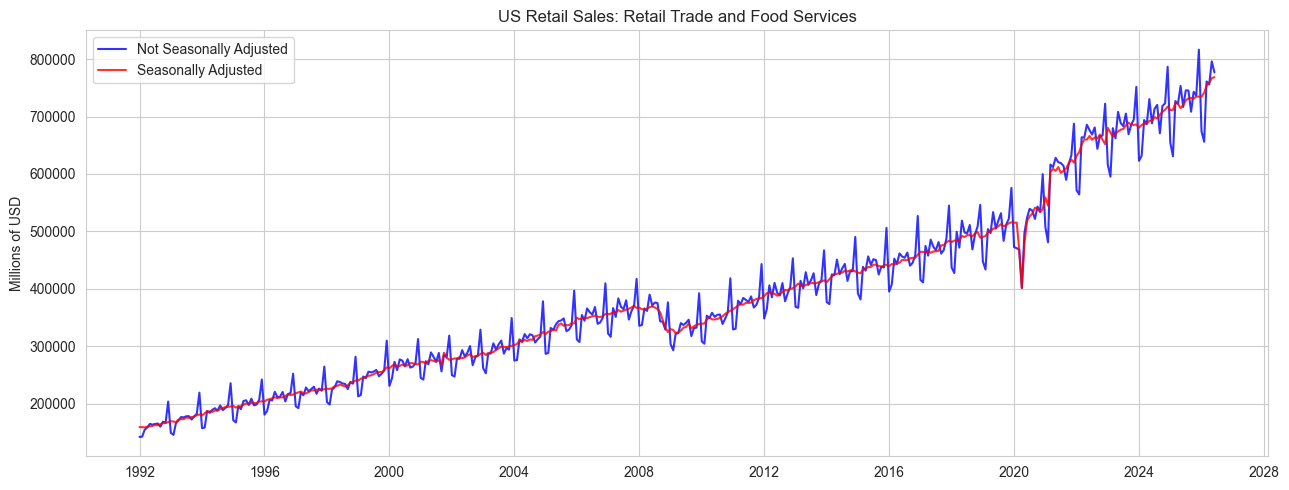

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index, df['retail_sales_nsa'], label='Not Seasonally Adjusted', color='BLUE', alpha=0.8)
ax.plot(df.index, df['retail_sales_sa'], label='Seasonally Adjusted', color='RED', alpha=0.8)
ax.set_title('US Retail Sales: Retail Trade and Food Services')
ax.set_ylabel('Millions of USD')
ax.legend()
plt.tight_layout()
plt.show()


**What to look for:** the NSA series should show a clear repeating
sawtooth pattern (December holiday-shopping spikes, January drop-offs) that
the SA series smooths out. If both lines look identical, something's wrong
with the fetch (e.g. accidentally pulling the same series twice).
